**Random Forest Classifier**

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
!pip install mediapipe


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 15.8 MB/s eta 0:00:00


In [2]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif


In [3]:
# Initialize Mediapipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

In [4]:
# Path to your dataset
dataset_dir = "/content/drive/MyDrive/Research/3lineDataset"  # Replace with your dataset path


In [5]:
dataset_dir

'/content/drive/MyDrive/Research/3lineDataset'

 **Get the image with angles and 3 lines**

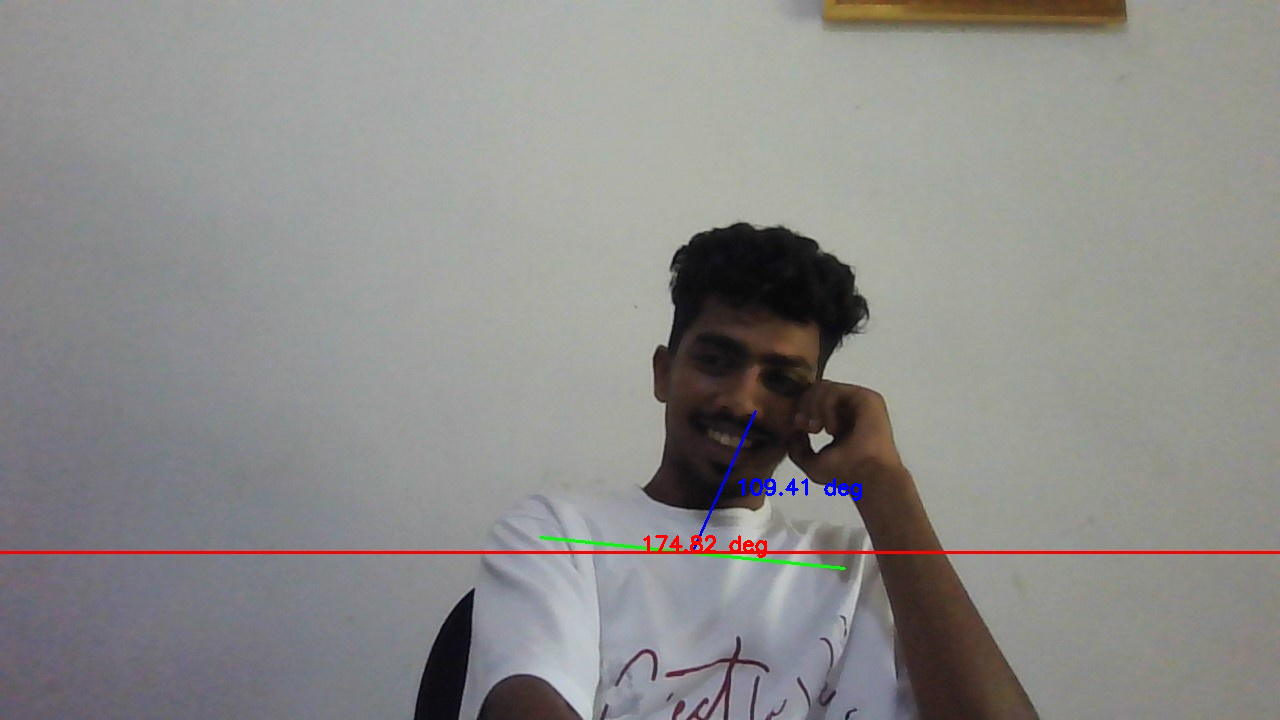

In [6]:
import cv2
import numpy as np
import os
import mediapipe as mp
from google.colab.patches import cv2_imshow  # For Colab display

# Initialize Mediapipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

def calculate_angle(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)
    angle = np.arccos(dot_product / (magnitude1 * magnitude2))
    return np.degrees(angle)

def annotate_image(image, draw_lines=True):
    """
    Annotates the given image with angle values.

    Parameters:
    - image: the input image.
    - draw_lines: if True, the function draws the green, red, and blue lines.
                  If False, it only adds the angle text to avoid duplicating lines.
    """
    # Process image for pose detection
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result = pose.process(image_rgb)

    if not result.pose_landmarks:
        print("No pose landmarks detected.")
        return image

    # Extract landmarks for left shoulder, right shoulder, and nose
    landmarks = result.pose_landmarks.landmark
    left_shoulder = (landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y)
    right_shoulder = (landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x,
                      landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y)
    nose = (landmarks[mp_pose.PoseLandmark.NOSE.value].x,
            landmarks[mp_pose.PoseLandmark.NOSE.value].y)

    # Convert normalized coordinates to absolute pixel coordinates
    h, w, _ = image.shape
    left_shoulder = (int(left_shoulder[0] * w), int(left_shoulder[1] * h))
    right_shoulder = (int(right_shoulder[0] * w), int(right_shoulder[1] * h))
    nose = (int(nose[0] * w), int(nose[1] * h))

    # Calculate midpoint between shoulders (vertex for angle measurements)
    mid_shoulder = ((left_shoulder[0] + right_shoulder[0]) // 2,
                    (left_shoulder[1] + right_shoulder[1]) // 2)

    # Calculate positions for the red horizontal reference line
    shoulder_length = int(np.linalg.norm(np.array(right_shoulder) - np.array(left_shoulder)))
    red_line_start = (mid_shoulder[0] - shoulder_length // 2, mid_shoulder[1])
    red_line_end = (mid_shoulder[0] + shoulder_length // 2, mid_shoulder[1])

    # Optionally draw the lines if they are not already present
    if draw_lines:
        # Draw green line: line connecting shoulders
        cv2.line(image, left_shoulder, right_shoulder, (0, 255, 0), 2)
        # Draw red line: horizontal reference line
        cv2.line(image, red_line_start, red_line_end, (0, 0, 255), 2)
        # Draw blue line: line from shoulder midpoint to nose
        cv2.line(image, mid_shoulder, nose, (255, 0, 0), 2)

    # Calculate vectors for the angle calculations
    green_line = np.array(right_shoulder) - np.array(left_shoulder)
    red_vector = np.array([1, 0])  # Horizontal reference vector
    blue_line = np.array(nose) - np.array(mid_shoulder)

    # Calculate angles
    angle_red_green = calculate_angle(red_vector, green_line)
    angle_blue_green = calculate_angle(blue_line, green_line)

    # Determine positions for angle text:
    # For the red-green angle, place text near the shoulder midpoint
    red_green_text_pos = (mid_shoulder[0] - 50, mid_shoulder[1] - 10)
    # For the blue-green angle, place text near the midpoint of the blue line
    blue_midpoint = ((mid_shoulder[0] + nose[0]) // 2, (mid_shoulder[1] + nose[1]) // 2)
    blue_green_text_pos = (blue_midpoint[0] + 10, blue_midpoint[1] + 10)

    # Annotate the image with angle values near the corresponding lines
    cv2.putText(image, f"{angle_red_green:.2f} deg", red_green_text_pos,
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(image, f"{angle_blue_green:.2f} deg", blue_green_text_pos,
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    return image

# Example usage:
image_path = "/content/drive/MyDrive/Research/3lineDataset/bad/bad_posture_147.jpg"  # Replace with your image file path
image = cv2.imread(image_path)
if image is not None:
    # If your image already has the green and blue lines drawn, set draw_lines=False
    annotated_image = annotate_image(image, draw_lines=False)
    cv2_imshow(annotated_image)
else:
    print("Image not found.")


In [7]:
# Function to calculate the angle between two vectors
def calculate_angle(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)
    angle = np.arccos(dot_product / (magnitude1 * magnitude2))
    return np.degrees(angle)

# Function to extract features and labels
def extract_features_and_labels(dataset_dir):
    features = []
    labels = []

    for label_folder, label in [("good", 1), ("bad", 0)]:
        label_dir = os.path.join(dataset_dir, label_folder)
        for filename in os.listdir(label_dir):
            if filename.endswith(".jpg") or filename.endswith(".png"):
                # Load image
                image_path = os.path.join(label_dir, filename)
                image = cv2.imread(image_path)
                if image is None:
                    continue

                # Process image using Mediapipe Pose
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                result = pose.process(image_rgb)

                if result.pose_landmarks:
                    landmarks = result.pose_landmarks.landmark

                    # Get landmark coordinates
                    left_shoulder = (landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
                                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y)
                    right_shoulder = (landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x,
                                      landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y)
                    nose = (landmarks[mp_pose.PoseLandmark.NOSE.value].x,
                            landmarks[mp_pose.PoseLandmark.NOSE.value].y)

                    # Convert to absolute pixel coordinates
                    h, w, _ = image.shape
                    left_shoulder = (int(left_shoulder[0] * w), int(left_shoulder[1] * h))
                    right_shoulder = (int(right_shoulder[0] * w), int(right_shoulder[1] * h))
                    nose = (int(nose[0] * w), int(nose[1] * h))

                    # Calculate vectors
                    green_line = np.array(right_shoulder) - np.array(left_shoulder)
                    red_line = np.array([1, 0])  # Horizontal reference vector
                    blue_line = np.array(nose) - np.array([(left_shoulder[0] + right_shoulder[0]) / 2,
                                                           (left_shoulder[1] + right_shoulder[1]) / 2])

                    # Calculate angles
                    angle_red_green = calculate_angle(red_line, green_line)
                    angle_blue_green = calculate_angle(blue_line, green_line)

                    # Append to features and labels
                    features.append([angle_red_green, angle_blue_green])
                    labels.append(label)

    return np.array(features), np.array(labels)


In [8]:
# Extract features and labels
features, labels = extract_features_and_labels(dataset_dir)

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [20]:
# Train a Random Forest model
model = RandomForestClassifier(n_estimators=160, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=160, random_state=42)

In [21]:
# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8507462686567164
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.88        38
           1       0.88      0.76      0.81        29

    accuracy                           0.85        67
   macro avg       0.86      0.84      0.84        67
weighted avg       0.85      0.85      0.85        67



In [ ]:
# Save the trained model
# import joblib
# joblib.dump(model, "posture_classifier.pkl")
# print("Model saved as posture_classifier.pkl")

In [ ]:
import h5py
import pickle

In [ ]:
# Serialize model using pickle
model_pkl = pickle.dumps(model)

In [ ]:
# Save the model as a .h5 file
with h5py.File("random_forest_model.h5", "w") as f:
    f.create_dataset("model", data=np.void(model_pkl))


In [ ]:
import joblib

joblib.dump(model, "random_forest_model.joblib")


['random_forest_model.joblib']